# Playground V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
import warnings

from typing import Callable, List, Literal, NamedTuple, Optional, Tuple, Union

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.metrics import pairwise_distances


import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'api', 'config', 'grids']
Classes: ['CARVE']
Functions: []


In [3]:
from carve import CARVE
from carve.config import ValidatorConfig

---

## 1. Data Simulation:

In [4]:
def _validate_center_box(center_box: float) -> float:
    if center_box < 0:
        warnings.warn('`center_box` should be positive; using abs(center_box).')
        center_box = -center_box
    if center_box == 0.0:
        warnings.warn('`center_box` was 0; defaulting to 10.0.')
        center_box = 10.0
    return center_box

def _lhs_centers(k: int, p: int, center_box: float, rng: np.random.Generator) -> np.ndarray:
    # latin hypercube: each dim gets a random permutation of k bins, with jitter inside each bin
    X = np.empty((k, p), dtype=float)
    
    for j in range(p):
        perm = rng.permutation(k)
        u = (perm + rng.random(k)) / k  # jitter inside each bin -> U(0,1)
        X[:, j] = -center_box + (2 * center_box) * u
        
    return X

def _best_candidate_centers(k: int, p: int, center_box: float, rng: np.random.Generator, n_candidates: int = 64) -> np.ndarray:
    centers = np.empty((k, p), dtype=float)
    centers[0] = rng.uniform(-center_box, center_box, size=p)
    
    for i in range(1, k):
        cands = rng.uniform(-center_box, center_box, size=(n_candidates, p))
        
        # compute squared distances to existing centers
        diffs = cands[:, None, :] - centers[None, :i, :]
        d2 = np.sum(diffs**2, axis=2)
        min_d2 = d2.min(axis=1)
        centers[i] = cands[np.argmax(min_d2)]
        
    return centers

def _min_dist_centers(k: int, p: int, center_box: float, rng: np.random.Generator, min_center_dist: float, max_tries: int = 200000) -> np.ndarray:
    centers = []
    tries = 0
    min2 = min_center_dist ** 2
    
    while len(centers) < k and tries < max_tries:
        c = rng.uniform(-center_box, center_box, size=p)
        if not centers:
            centers.append(c)
        else:
            cc = np.vstack(centers)
            if np.all(np.sum((cc - c) ** 2, axis=1) >= min2):
                centers.append(c)
        tries += 1
        
    if len(centers) < k:
        raise ValueError(f"could not place {k} centers with min_center_dist={min_center_dist}. try reducing it or enlarging center_box.")
    
    return np.vstack(centers)

def _sample_cluster_sizes(
    n_total: int,
    k: int,
    rng: np.random.Generator,
    min_abs: int = 5,
    min_frac: float = 0.1,
    alpha: float | np.ndarray = 0.3,
    ensure_nonempty: bool = True
) -> np.ndarray:
    """
    Returns integer sizes summing to n_total with floors enforced.
    Strategy: allocate the guaranteed minimum first, then distribute the remainder
    via Multinomial with probabilities from a Dirichlet(alpha).
    """
    if n_total <= 0 or k <= 0:
        raise ValueError("n_total and k must be positive.")
    if min_abs < 0 or min_frac < 0:
        raise ValueError("min_abs and min_frac must be nonnegative.")
    if isinstance(alpha, np.ndarray) and alpha.shape != (k,):
        raise ValueError("alpha must be scalar or shape (k,).")

    # per-cluster floor
    floor_each = max(min_abs, int(np.ceil(min_frac * n_total)))
    if ensure_nonempty:
        floor_each = max(floor_each, 1)

    total_floor = floor_each * k
    if total_floor > n_total:
        raise ValueError(
            f"Infeasible: k * floor_each = {k} * {floor_each} = {total_floor} > n_total = {n_total}. "
            "Reduce k / floors or increase n_total."
        )

    # assign floors, then distribute the remainder
    sizes = np.full(k, floor_each, dtype=int)
    remaining = n_total - total_floor
    if remaining == 0:
        return sizes

    # Dirichlet probs -> Multinomial integer split
    a = np.full(k, alpha, dtype=float) if np.isscalar(alpha) else alpha.astype(float)
    probs = rng.dirichlet(a)
    sizes += rng.multinomial(remaining, probs)
    return sizes

def _parse_outliers(outliers: int | float, n_total: int) -> int:
    if isinstance(outliers, float) and 0 < outliers < 1:
        return int(np.floor(n_total * outliers))
    elif isinstance(outliers, int) and outliers >= 0:
        return outliers
    else:
        warnings.warn("`outliers` must be a non-negative int or a float in (0, 1). Defaulting to 0.")
        return 0

def _compute_cluster_sizes(
    *, n_total_clusters: int, k: int, balanced: bool,
    cluster_sizes_frac: list[float] | None,
    rng: np.random.Generator,
    min_abs: int, min_frac: float, alpha: float | np.ndarray
) -> np.ndarray:
    if cluster_sizes_frac is not None:
        if len(cluster_sizes_frac) != k:
            raise ValueError(f"cluster_sizes_frac must have length k={k}.")
        
        total = float(np.sum(cluster_sizes_frac))
        if abs(total - 1.0) > 1e-8:
            warnings.warn("`cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.")
            cluster_sizes_frac = [frac / total for frac in cluster_sizes_frac]
        sizes = [int(np.floor(n_total_clusters * frac)) for frac in cluster_sizes_frac]
        
        # distribute remainder
        for i in range(n_total_clusters - int(np.sum(sizes))):
            sizes[i % k] += 1
        
        return np.asarray(sizes, dtype=int)

    elif balanced:
        base = n_total_clusters // k
        sizes = [base] * k
        for i in range(n_total_clusters - base * k):
            sizes[i] += 1
        return np.asarray(sizes, dtype=int)

    else:  # unbalanced with constraints
        return _sample_cluster_sizes(
            n_total=n_total_clusters,
            k=k,
            rng=rng,
            min_abs=min_abs,
            min_frac=min_frac,
            alpha=alpha
        )

def _get_cluster_scales(cluster_scale, k: int) -> list[float]:
    if callable(cluster_scale):
        return [float(cluster_scale()) for _ in range(k)]
    
    elif isinstance(cluster_scale, list):
        if len(cluster_scale) != k:
            raise ValueError("Passed `cluster_scale` parameter must be of size k.")
        return [float(x) for x in cluster_scale]
    
    else:
        return [float(cluster_scale)] * k

def _sample_centers(
    *, k: int, p: int, center_box: float, rng: np.random.Generator,
    method: Literal["none", "lhs", "best_candidate", "min_dist"],
    n_candidates: int, min_center_dist: float | None
) -> np.ndarray:
    center_box = _validate_center_box(center_box)
    if method == "none":
        return rng.uniform(-center_box, center_box, size=(k, p))
    
    elif method == "lhs":
        return _lhs_centers(k, p, center_box, rng)
    
    elif method == "best_candidate":
        return _best_candidate_centers(k, p, center_box, rng, n_candidates=n_candidates)
    
    elif method == "min_dist":
        if min_center_dist is None:
            diag = 2 * center_box * np.sqrt(p)
            min_center_dist = 0.05 * diag
        return _min_dist_centers(k, p, center_box, rng, min_center_dist=min_center_dist)
    
    else:
        raise ValueError(f"unknown centroid_method: {method}")

def _build_correlation_matrix(
    *, p: int, corr_type: Literal["none", "ar1", "block"], corr_strength: float, block_size: int | None
) -> np.ndarray:
    if corr_type == "none":
        return np.eye(p)
    
    elif corr_type == "ar1":
        idx = np.arange(p)
        return corr_strength ** np.abs(idx[:, None] - idx[None, :])
    
    elif corr_type == "block":
        if block_size is None:
            raise ValueError("`block_size` must be provided when corr_type='block'")
        
        R = np.zeros((p, p))
        for start in range(0, p, block_size):
            end = min(start + block_size, p)
            R[start:end, start:end] = corr_strength
        np.fill_diagonal(R, 1.0)
        
        return R
    
    else:
        raise ValueError(f"Unknown corr_type `{corr_type}`")

def _cluster_covariances(scales: list[float], R: np.ndarray) -> list[np.ndarray]:
    return [s * R for s in scales]

def _sample_cluster_points(
    *, rng: np.random.Generator, size: int, mean: np.ndarray, cov: np.ndarray,
    distribution: Literal["gaussian", "t", "uniform_ball", "circles", "moons", "swiss_roll"], t_df: int
) -> np.ndarray:
    p = mean.shape[0]
    if size == 0:
        return np.empty((0, p), dtype=float)

    if distribution == "gaussian":
        return rng.multivariate_normal(mean=mean, cov=cov, size=size)
    
    elif distribution == "t":
        # X = μ + L z * sqrt(df / v), z~N(0,I), v~χ²(df)
        L = np.linalg.cholesky(cov)
        z = rng.standard_normal((size, p))
        v = rng.chisquare(t_df, size=(size, 1))
        return mean + (z @ L.T) * np.sqrt(t_df / v)
    
    elif distribution == "uniform_ball":
        # uniform in p-ball, radius tied to covariance scale
        r_max = np.sqrt(np.trace(cov) / p)
        U = rng.standard_normal((size, p))
        U /= np.linalg.norm(U, axis=1, keepdims=True)
        radii = rng.random(size) ** (1.0 / p) * r_max
        return mean + U * radii.reshape(-1, 1)
    
    elif distribution == "circles":
        # Single annulus in 2D, then warp by cov and shift by mean
        if p < 2:
            raise ValueError("`circles` distribution requires p >= 2.")
        theta = rng.uniform(0.0, 2.0 * np.pi, size=size)
        thickness = 0.08  # relative radial thickness
        r = 1.0 + rng.normal(scale=thickness, size=size)
        Z2 = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)

        Z = np.zeros((size, p), dtype=float)
        Z[:, :2] = Z2

        # center and standardize to roughly unit scale before applying cov
        Z -= Z.mean(axis=0, keepdims=True)
        std = Z.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        Z /= std

        L = np.linalg.cholesky(cov)
        return mean + Z @ L.T

    elif distribution == "moons":
        # Single crescent (half circle) in 2D, then warp by cov and shift by mean
        if p < 2:
            raise ValueError("`moons` distribution requires p >= 2.")
        theta = rng.uniform(0.0, np.pi, size=size)
        r = 1.0 + rng.normal(scale=0.04, size=size)  # thin band
        x = r * np.cos(theta) + 0.4  # shift to create a crescent-like arc
        y = r * np.sin(theta) + rng.normal(scale=0.04, size=size)  # thickness

        Z2 = np.stack([x, y], axis=1)
        Z = np.zeros((size, p), dtype=float)
        Z[:, :2] = Z2

        # center and standardize
        Z -= Z.mean(axis=0, keepdims=True)
        std = Z.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        Z /= std

        L = np.linalg.cholesky(cov)
        return mean + Z @ L.T

    elif distribution == "swiss_roll":
        # 3D swiss roll manifold -> embed to p dims, warp by cov, shift by mean
        try:
            from sklearn.datasets import make_swiss_roll
        except Exception as e:
            raise ImportError("scikit-learn is required for `swiss_roll`.") from e

        X0, _ = make_swiss_roll(
            n_samples=size, noise=0.05, random_state=int(rng.integers(0, 1_000_000))
        )
        Z3 = X0.astype(float)

        # center and standardize 3D roll
        Z3 -= Z3.mean(axis=0, keepdims=True)
        std3 = Z3.std(axis=0, keepdims=True)
        std3[std3 == 0] = 1.0
        Z3 /= std3

        Z = np.zeros((size, p), dtype=float)
        if p >= 3:
            Z[:, :3] = Z3
        else:
            # project to first p coordinates if p < 3
            Z[:, :p] = Z3[:, :p]

        # re-standardize across p dims (safe if many zeros)
        Z -= Z.mean(axis=0, keepdims=True)
        std = Z.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        Z /= std

        L = np.linalg.cholesky(cov)
        return mean + Z @ L.T

    else:
        raise ValueError("`distribution` must be one of: {'gaussian', 't', 'uniform_ball', 'circles', 'moons', 'swiss_roll'}.")

def _sample_outliers(
    *, rng: np.random.Generator, n_outliers: int, p: int,
    centers: np.ndarray, cluster_sizes: np.ndarray, covs: list[np.ndarray],
    center_box: float, outlier_mode: Literal["far_gaussian", "uniform_box"], outlier_scale: float
) -> np.ndarray:
    if n_outliers <= 0:
        return np.empty((0, p), dtype=float)

    # weighted centroid + avg covariance
    weights = cluster_sizes.astype(float)
    global_centroid = np.average(centers, axis=0, weights=weights)
    avg_cov = sum(w * C for w, C in zip(weights, covs)) / weights.sum()
    global_sigma = float(np.sqrt(np.mean(np.diag(avg_cov))))

    if outlier_mode == "far_gaussian":
        U = rng.standard_normal(size=(n_outliers, p))
        U /= np.linalg.norm(U, axis=1, keepdims=True)
        return global_centroid + outlier_scale * global_sigma * U

    elif outlier_mode == "uniform_box":
        box = _validate_center_box(center_box) * outlier_scale
        return rng.uniform(-box, +box, size=(n_outliers, p))

    else:
        raise ValueError(f"unknown outlier_mode `{outlier_mode}`")

def _apply_embedding(
    X: np.ndarray, *, nonlinear: bool, method: Literal["random_fourier", "poly", "rbf"],
    embed_dim: int | None, embed_param: float, rng: np.random.Generator
) -> np.ndarray:
    if not nonlinear:
        return X

    if method == "random_fourier" or method == "fourier":
        if embed_dim is None:
            raise ValueError("embed_dim must be provided for random_fourier")
        freq_scale = 0.1
        W = rng.normal(scale=freq_scale, size=(X.shape[1], embed_dim))
        b = rng.uniform(0, 2 * np.pi, size=(embed_dim,))
        return np.sin(X @ W + b)

    elif method == "poly":
        d = embed_param
        # simple example: original + power + pairwise product of first two dims (if present)
        cols = [X, X**d]
        if X.shape[1] >= 2:
            cols.append((X[:, [0]] * X[:, [1]]))
        return np.hstack(cols)

    elif method == "rbf":
        sigma_rbf = embed_param
        m = min(50, len(X))
        prototypes = X[rng.choice(len(X), size=m, replace=False)]
        gamma = 1.0 / (2.0 * sigma_rbf**2)
        return np.exp(-gamma * ((X[:, None, :] - prototypes[None, :, :]) ** 2).sum(-1))

    else:
        raise ValueError(f"Unknown embed_method `{method}`")

def _plot_simulation(X: np.ndarray, y: np.ndarray, *, random_state: int | None):
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    # scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab10', edgecolors='k', alpha=0.8)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', edgecolors='k', alpha=0.8)
    plt.title("PCA projection of simulated clusters")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout(); plt.show()

class SimulationMeta(NamedTuple):
    centers: np.ndarray
    cluster_sizes: np.ndarray
    cluster_scales: list[float]
    correlation: np.ndarray
    covariances: list[np.ndarray]
    outliers: int

In [5]:
def simulate_clusters(
    n_total: int,
    p: int,
    k: int,
    cluster_scale: float | list[float] | Callable[[], float] = 1.0,
    balanced: bool = True,
    cluster_sizes_frac: list[float] | None = None,
    min_cluster_size_abs: int = 5,
    min_cluster_size_frac: float = 0.1,
    cluster_size_dirichlet_alpha: float | np.ndarray = 0.3,
    corr_type: Literal["none", "ar1", "block"] = "none",
    corr_strength: float = 1.0,
    block_size: int | None = None,
    outliers: int | float = 0,
    outlier_scale: float = 5.0,
    outlier_mode: Literal["far_gaussian", "uniform_box"] = "far_gaussian",
    distribution: Literal["gaussian", "t", "uniform_ball"] = "gaussian",
    t_df: int = 3,
    nonlinear: bool = False,
    embed_dim: int | None = None,
    embed_method: Literal["random_fourier", "poly", "rbf"] = "random_fourier",
    embed_param: float = 2.0,
    center_box: float = 10.0,
    centroid_method: Literal["none", "lhs", "best_candidate", "min_dist"] = "best_candidate",
    n_candidates: int = 64,
    min_center_dist: float | None = None,
    plotting: bool = True,
    random_state: int | None = None
) -> Tuple[np.ndarray, np.ndarray, SimulationMeta]:
    """
    Generate synthetic clustered data with optional correlation, outliers, and embedding.

    Returns: (X, y, meta)
      - X: (n_total, p) array
      - y: (n_total,) labels, 0..k-1 for clusters, -1 for outliers
      - meta: SimulationMeta with centers, sizes, scales, correlation, covariances, outliers
    """
    rng = np.random.default_rng(seed=random_state)

    # Outliers
    n_outliers = _parse_outliers(outliers, n_total)
    n_total_clusters = n_total - n_outliers
    if n_total_clusters < 1:
        raise ValueError("`outliers` too large, no points left for clusters.")

    # Sizes
    cluster_sizes = _compute_cluster_sizes(
        n_total_clusters=n_total_clusters,
        k=k,
        balanced=balanced,
        cluster_sizes_frac=cluster_sizes_frac,
        rng=rng,
        min_abs=min_cluster_size_abs,
        min_frac=min_cluster_size_frac,
        alpha=cluster_size_dirichlet_alpha
    )
    assert int(cluster_sizes.sum()) == n_total_clusters

    # Centers and covariances
    centers = _sample_centers(
        k=k, p=p, center_box=center_box, rng=rng,
        method=centroid_method, n_candidates=n_candidates, min_center_dist=min_center_dist
    )
    scales = _get_cluster_scales(cluster_scale, k)
    R = _build_correlation_matrix(p=p, corr_type=corr_type, corr_strength=corr_strength, block_size=block_size)
    covs = _cluster_covariances(scales, R)

    # Sample clusters
    X_parts: list[np.ndarray] = []
    y_parts: list[np.ndarray] = []
    for c in range(k):
        size = int(cluster_sizes[c])
        mean = centers[c]
        cov = covs[c]
        X_c = _sample_cluster_points(
            rng=rng, size=size, mean=mean, cov=cov,
            distribution=distribution, t_df=t_df
        )
        X_parts.append(X_c)
        y_parts.append(np.full(size, c, dtype=int))

    # Outliers
    if n_outliers > 0:
        X_out = _sample_outliers(
            rng=rng, n_outliers=int(n_outliers), p=p,
            centers=centers, cluster_sizes=cluster_sizes, covs=covs,
            center_box=center_box, outlier_mode=outlier_mode, outlier_scale=outlier_scale
        )
        X_parts.append(X_out)
        y_parts.append(np.full(int(n_outliers), -1, dtype=int))

    # Concatenate and shuffle
    X = np.vstack(X_parts) if X_parts else np.empty((0, p), dtype=float)
    y = np.concatenate(y_parts) if y_parts else np.empty((0,), dtype=int)

    perm = rng.permutation(len(y))
    X = X[perm]
    y = y[perm]

    # Optional embedding
    X = _apply_embedding(
        X, nonlinear=nonlinear, method=embed_method, embed_dim=embed_dim,
        embed_param=embed_param, rng=rng
    )

    # Optional plotting
    if plotting:
        _plot_simulation(X, y, random_state=random_state)

    meta = SimulationMeta(
        centers=centers, cluster_sizes=cluster_sizes, cluster_scales=scales,
        correlation=R, covariances=covs, outliers=int(n_outliers)
    )
    return X, y, meta

---

## 2. Playground

In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


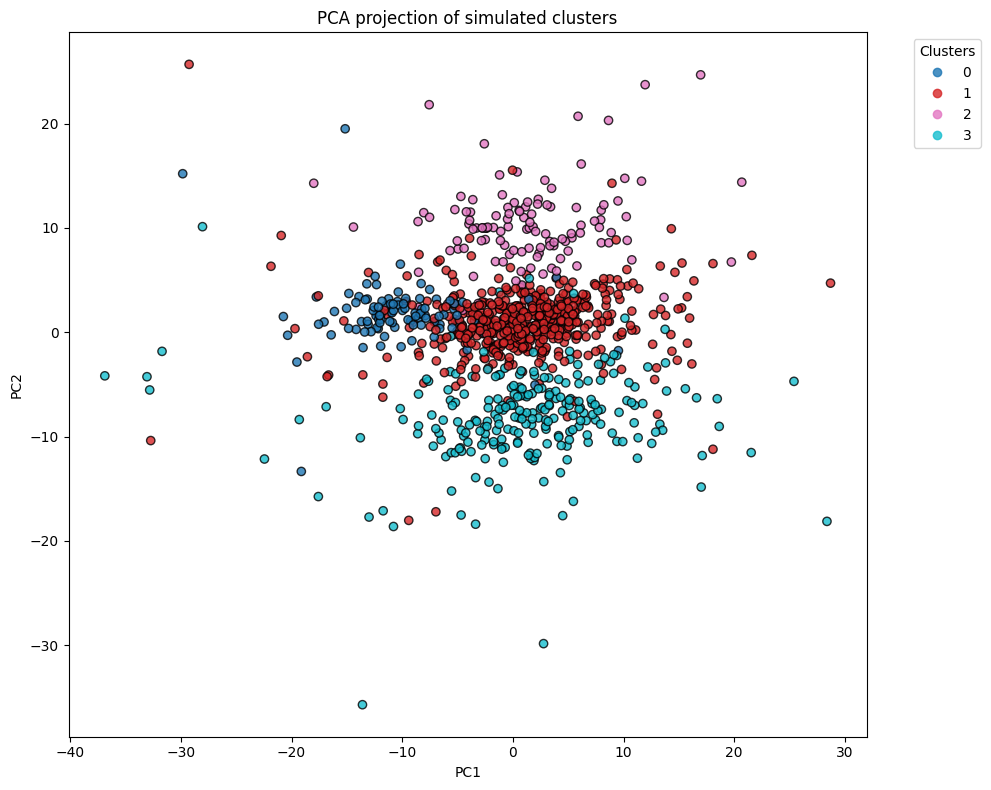

In [7]:
f=7.5

X3, y3, m3 = simulate_clusters(
    n_total=1000, p=4, k=4,
    balanced=False,
    cluster_size_dirichlet_alpha=0.15,  # strong imbalance
    cluster_scale=[f * s for s in [0.5, 0.8, 1.4, 2.0]],
    corr_type="ar1", corr_strength=0.75,  # correlated features
    distribution="t", t_df=3,             # heavier tails
    centroid_method="min_dist", min_center_dist=6.0,
    center_box=10.0,
    random_state=33
)


In [8]:
# # D2_1 = pairwise_distances(X1, metric='sqeuclidean')
# # median_d2_1 = np.median(D2_1[np.triu_indices_from(D2_1, k=1)])
# # gamma0_1 = 1.0 / (2.0 * median_d2_1) if median_d2_1 > 0 else 1.0
# # gamma0_1 = [gamma0_1]
# # gamma0_1 = np.logspace(np.log10(gamma0_1) - 1, np.log10(gamma0_1) + 1, num=3)

# ks = list(range(2, 9))
# # ks = list(range(2, 5))
    
# # model_grids1 = [
# #     (KMeans, {"n_clusters": ks}),
# #     (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
# #     (SpectralClustering, {"n_clusters": ks, "gamma": gamma0_1})
# # ]

# cfg1 = ValidatorConfig(
#     X=X,
#     ref_labels=y
# )

# val1 = CARVE(cfg1)
# val1.validate(random_state=42)

In [9]:
cfg1 = ValidatorConfig(
    X=X3,
    ref_labels=y3
)

val1 = CARVE(cfg1)
val1.validate(random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

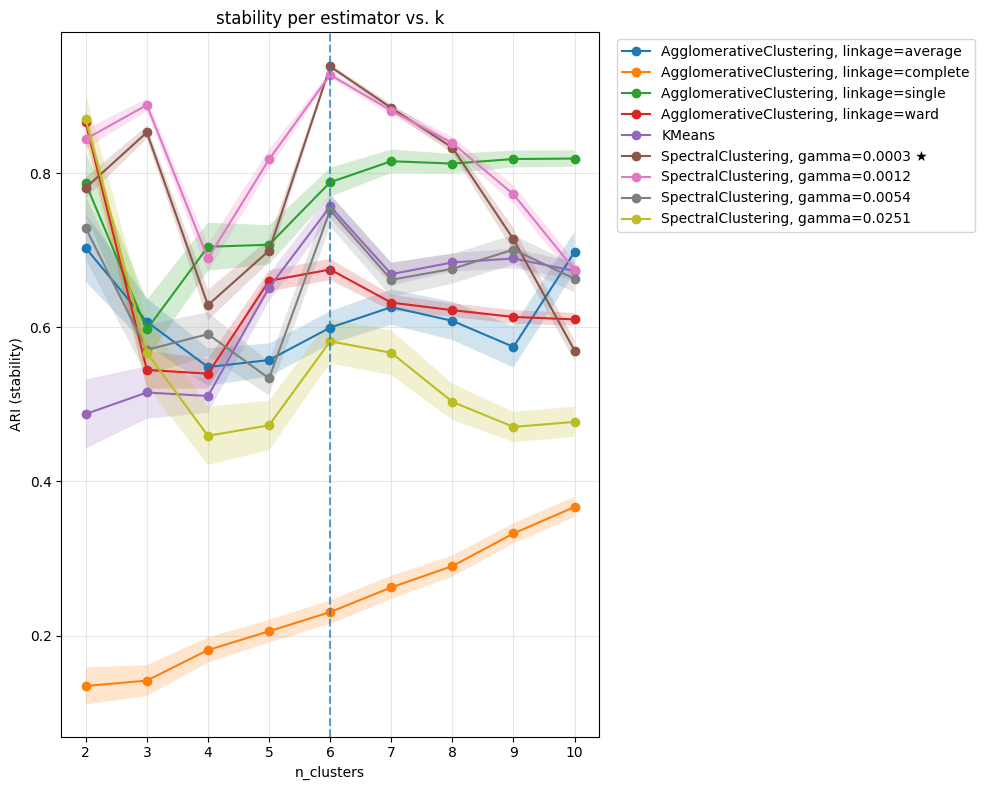

In [10]:
val1.plot_global(measure='stability', rule='1se')

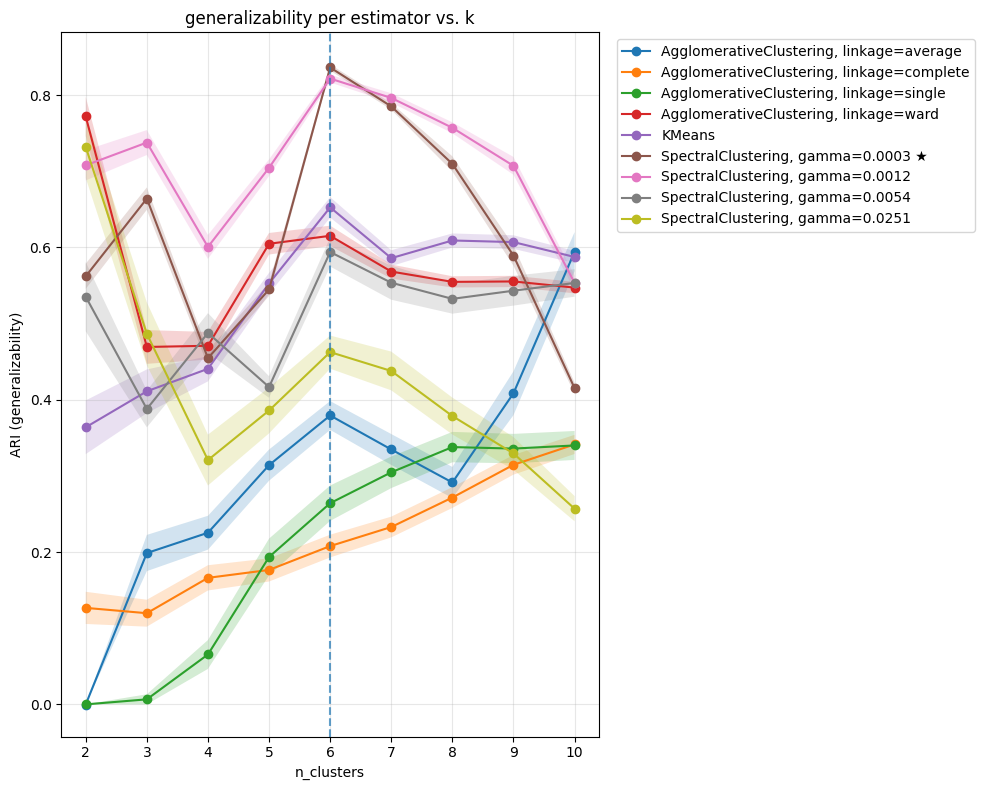

In [11]:
val1.plot_global(measure='generalizability', rule='1se')

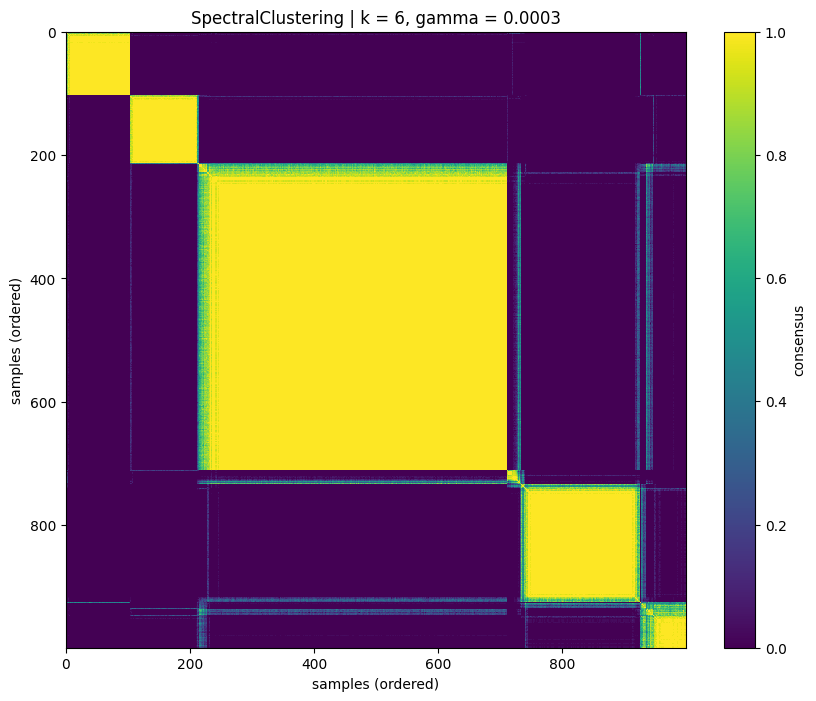

In [25]:
val1.plot_consensus_matrix(measure='s', rule='1se')

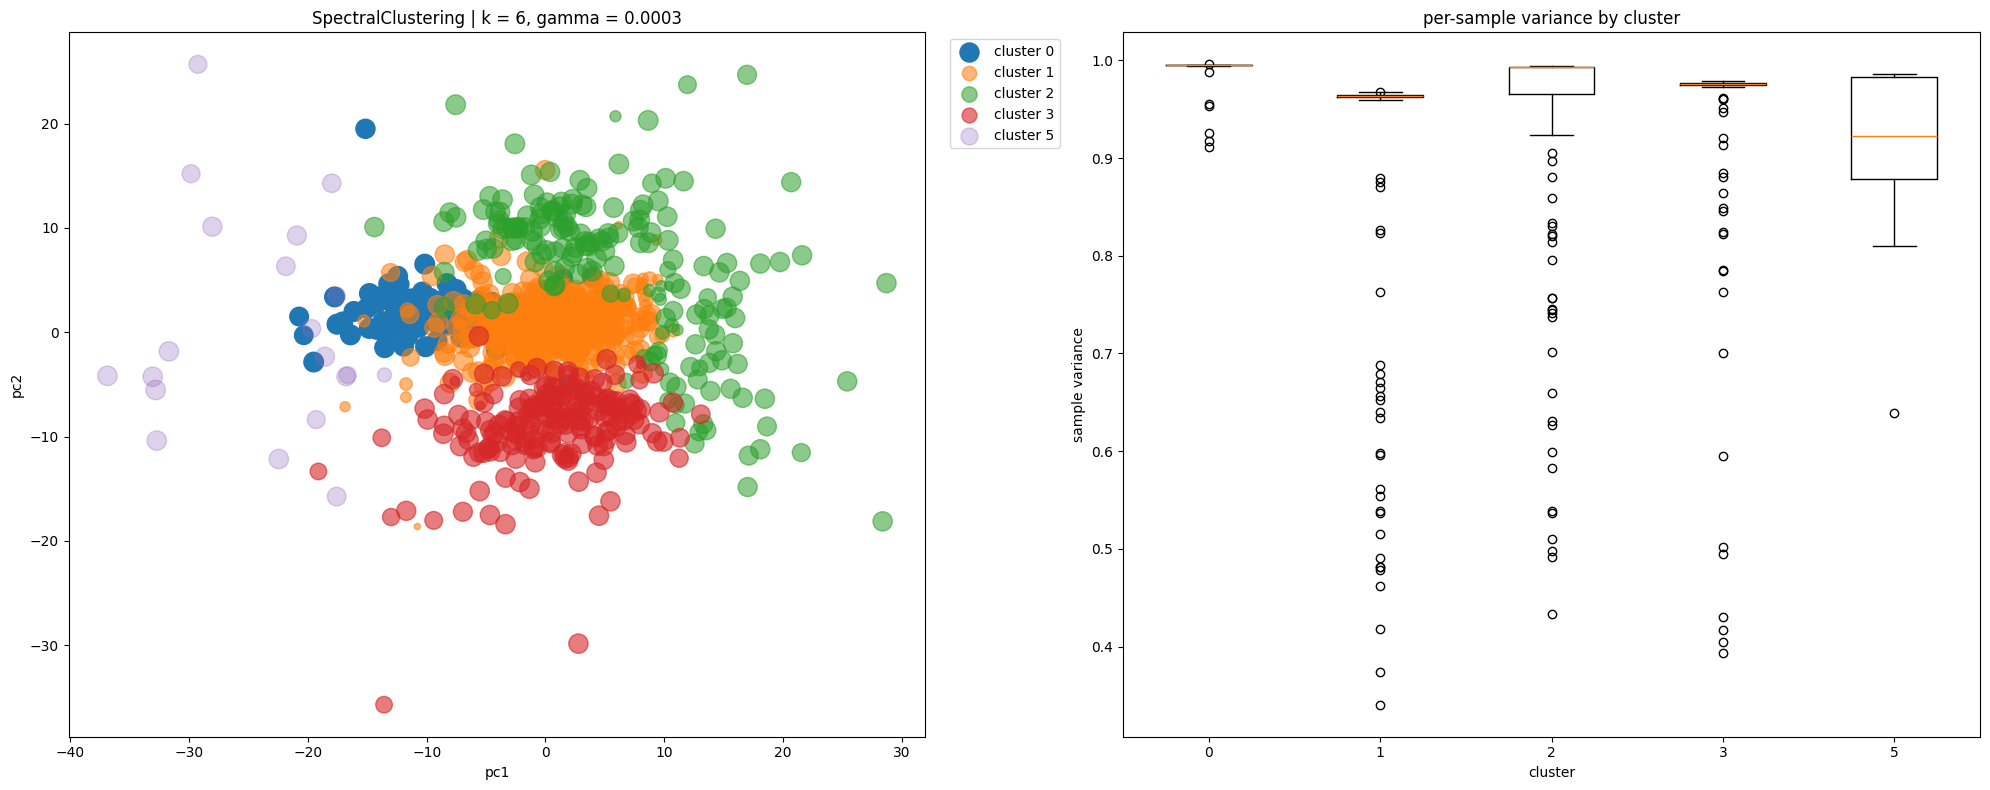

In [40]:
val1.plot_clustering(measure='s', rule='1se')

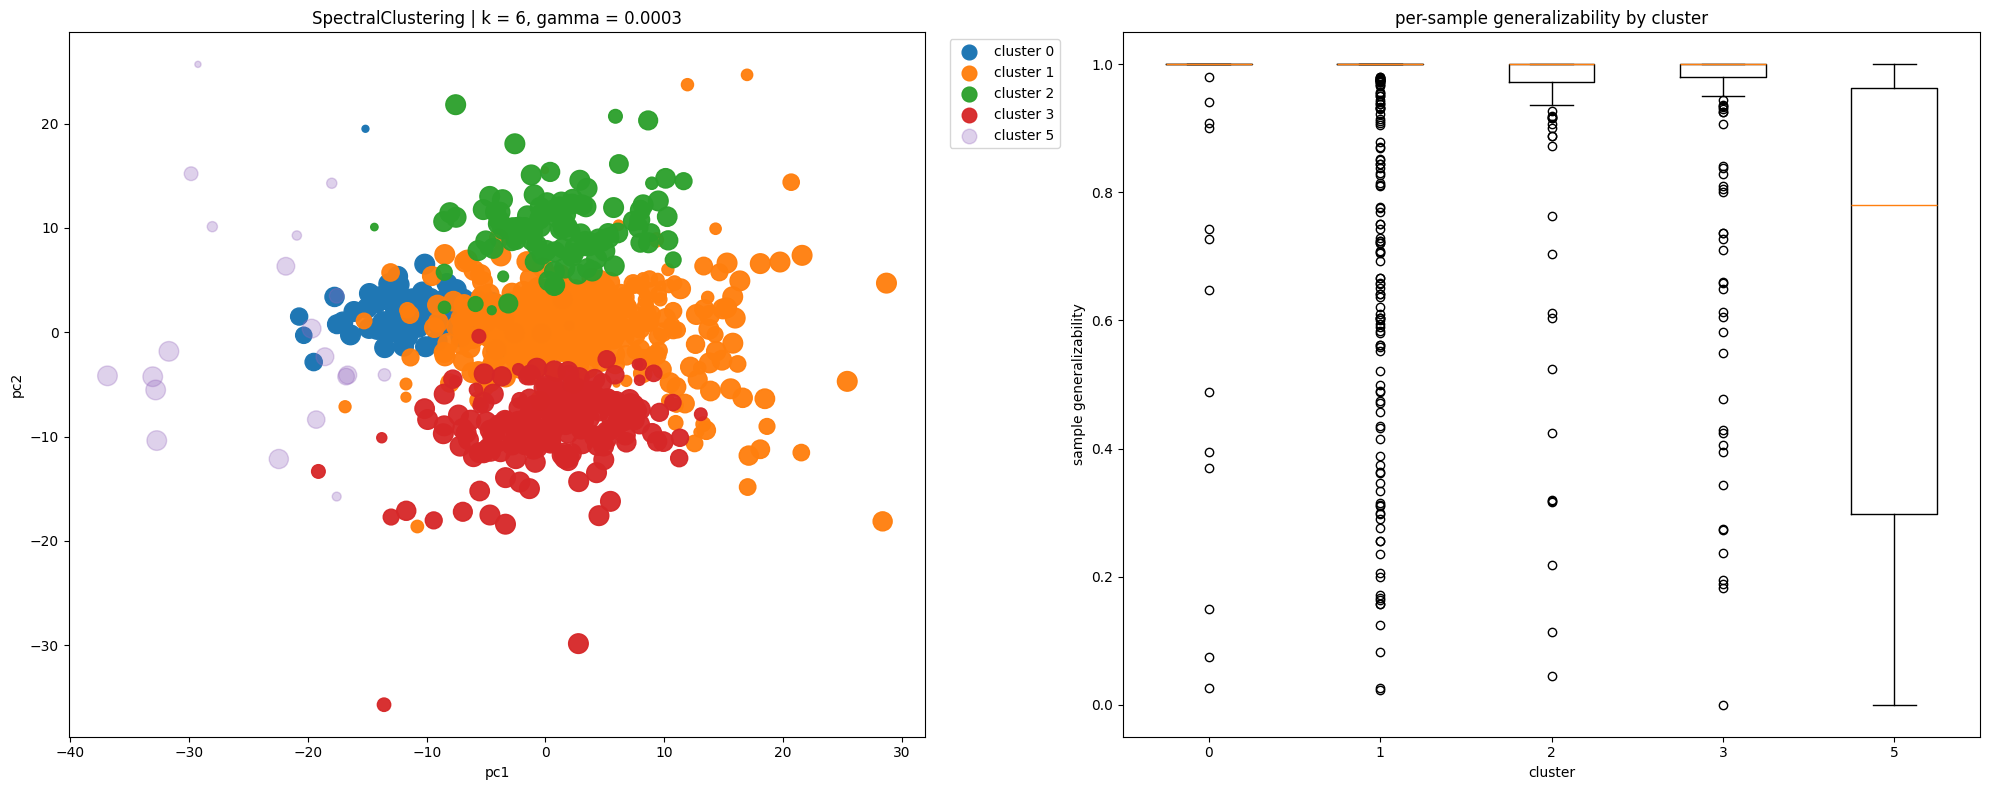

In [37]:
val1.plot_clustering(measure='g', rule='1se')